In [9]:
!pip install -q git+https://github.com/RayenSansa03/aeroguard.git@main --force-reinstall --no-deps
!nvidia-smi --query-gpu=name --format=csv

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
name
Tesla T4


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost
from aeroguard.donnees_ml import preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"
vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")
colonnes = list(X_val.columns)

xgb_bin = xgboost.XGBClassifier()
xgb_bin.load_model(f"{DOSSIER}/models/xgb_binaire_v3.json")   # sauvegardé en 3.2
booster = xgb_bin.get_booster()
print("Modèle chargé :", booster.num_boosted_rounds(), "arbres")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modèle chargé : 461 arbres


In [3]:
dval = xgboost.DMatrix(X_val)
dtrain = xgboost.DMatrix(X_train)

temps = {}
for device in ["cuda", "cpu"]:
    booster.set_param({"device": device})
    debut = time.perf_counter()
    booster.predict(dtrain, pred_contribs=True)
    temps[device] = time.perf_counter() - debut
print(f"SHAP sur {len(X_train)} vols — GPU : {temps['cuda']:.2f} s | CPU : {temps['cpu']:.2f} s")

contrib = booster.predict(dval, pred_contribs=True)   # (vols, 126 features + 1 « départ »)
shap_val = contrib[:, :-1]
depart = contrib[0, -1]

# Vérification : départ + somme des SHAP = score du modèle (avant sigmoïde)
score = booster.predict(dval, output_margin=True)
print("Écart max (doit être ≈ 0) :", np.abs(depart + shap_val.sum(axis=1) - score).max())

SHAP sur 3716 vols — GPU : 0.17 s | CPU : 1.99 s
Écart max (doit être ≈ 0) : 1.2397766e-05


,feature,importance,description
0,T50_mean_montee,1.216896,T50 moyenne en montée
1,T48_mean_montee,1.117863,T48 moyenne en montée
2,T50_mean_croisiere,0.671023,T50 moyenne en croisière
3,T50_mean_descente,0.288718,T50 moyenne en descente
4,T48_mean_croisiere,0.261621,T48 moyenne en croisière
5,P40_mean_montee,0.247959,P40 moyenne en montée
6,Nc_mean_montee,0.234374,Nc moyenne en montée
7,T48_mean_descente,0.208671,T48 moyenne en descente
8,P50_mean_montee,0.204630,P50 moyenne en montée
9,T50_max_montee,0.187008,T50 maximum en montée


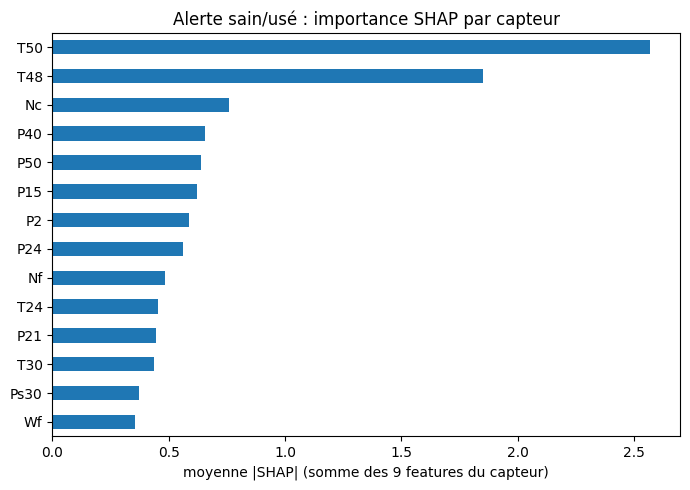

In [4]:
from aeroguard.explication import importance_par_capteur, importances_triees

importance = np.abs(shap_val).mean(axis=0)
top = importances_triees(importance, colonnes, n=10)
display(top)

par_capteur = importance_par_capteur(importance, colonnes)
par_capteur.iloc[::-1].plot.barh(figsize=(7, 5))
plt.title("Alerte sain/usé : importance SHAP par capteur")
plt.xlabel("moyenne |SHAP| (somme des 9 features du capteur)")
plt.tight_layout()
plt.show()

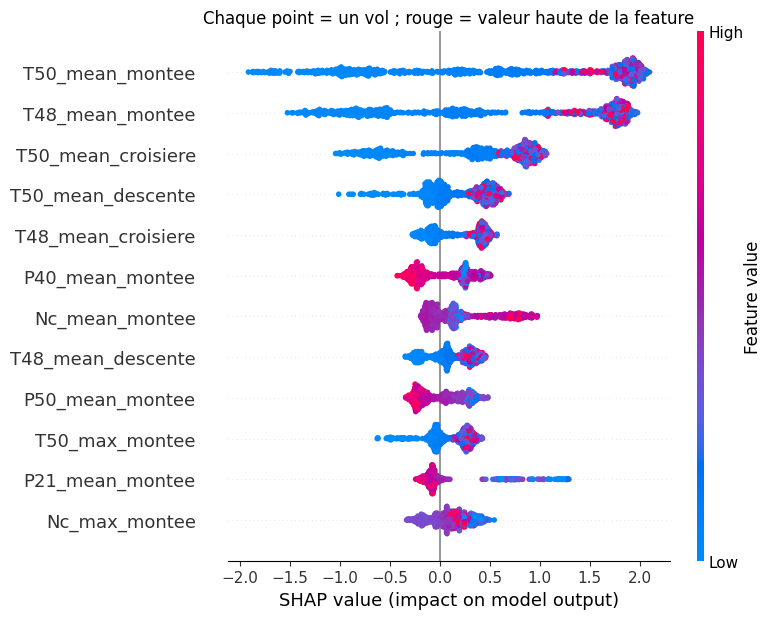

In [5]:
import shap

shap.summary_plot(shap_val, X_val, max_display=12, show=False)
plt.title("Chaque point = un vol ; rouge = valeur haute de la feature")
plt.tight_layout()
plt.show()

In [6]:
from aeroguard.explication import expliquer_vol

SEUIL = 0.81                                       # le seuil choisi en 3.2
proba = xgb_bin.predict_proba(X_val)[:, 1]
infos = vols.loc[X_val.index, ["moteur", "cycle", "RUL"]].reset_index(drop=True)
infos["proba"] = proba
infos["y"] = y_val.values

alerte = infos[(infos["moteur"] == "DS01_1") & (infos["proba"] >= SEUIL) & (infos["y"] == 1)]
i = alerte.sort_values("cycle").index[0]           # la PREMIÈRE vraie alerte de ce moteur
print(f"Moteur DS01_1 — vol {infos.loc[i, 'cycle']} — RUL {infos.loc[i, 'RUL']} — "
      f"probabilité d'usure {infos.loc[i, 'proba']:.0%}")
expliquer_vol(shap_val[i], colonnes, n=5).round(2)

Moteur DS01_1 — vol 37 — RUL 63 — probabilité d'usure 91%


,feature,contribution,description,sens
0,T50_mean_montee,0.77,T50 moyenne en montée,pour
1,T50_mean_croisiere,0.47,T50 moyenne en croisière,pour
2,T48_mean_montee,0.35,T48 moyenne en montée,pour
3,P40_mean_montee,-0.29,P40 moyenne en montée,contre
4,P50_mean_montee,-0.22,P50 moyenne en montée,contre


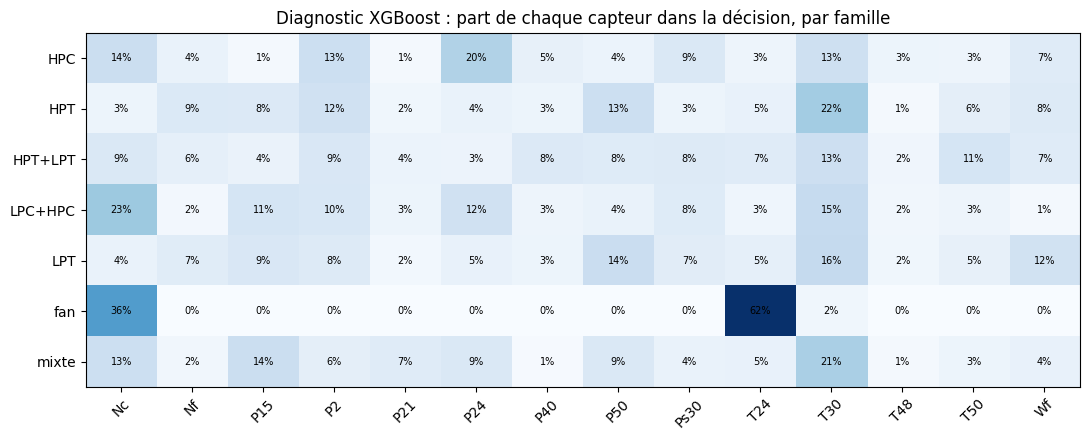

In [7]:
from sklearn.preprocessing import LabelEncoder
from aeroguard.donnees_ml import preparer_xy_famille

Xf_train, fam_train = preparer_xy_famille(vols, "train")
Xf_val, fam_val = preparer_xy_famille(vols, "val")
encodeur = LabelEncoder().fit(fam_train)
familles = list(encodeur.classes_)

xgb_diag = xgboost.XGBClassifier()
xgb_diag.load_model(f"{DOSSIER}/models/xgb_diagnostic_regle_v3.json")   # sauvegardé en 3.4
b_diag = xgb_diag.get_booster()
b_diag.set_param({"device": "cuda"})
contrib_diag = b_diag.predict(xgboost.DMatrix(Xf_val), pred_contribs=True)  # (vols, familles, 127)

carte = pd.DataFrame({
    fam: importance_par_capteur(np.abs(contrib_diag[:, k, :-1]).mean(axis=0), colonnes)
    for k, fam in enumerate(familles)
}).T
carte = carte.div(carte.sum(axis=1), axis=0)       # en part du total de chaque famille

plt.figure(figsize=(11, 4.5))
plt.imshow(carte.values, cmap="Blues", aspect="auto")
plt.xticks(range(carte.shape[1]), carte.columns, rotation=45)
plt.yticks(range(len(familles)), familles)
for r in range(carte.shape[0]):
    for c in range(carte.shape[1]):
        plt.text(c, r, f"{carte.values[r, c]:.0%}", ha="center", va="center", fontsize=7)
plt.title("Diagnostic XGBoost : part de chaque capteur dans la décision, par famille")
plt.tight_layout()
plt.show()

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

y_ftrain = encodeur.transform(fam_train)
logi = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
logi.fit(Xf_train, y_ftrain,
         logisticregression__sample_weight=compute_sample_weight("balanced", y_ftrain))

# Pour une logistique, la contribution d'une feature = coefficient × valeur standardisée
x_std = logi.named_steps["standardscaler"].transform(Xf_val)
coefs = logi.named_steps["logisticregression"].coef_          # (familles, 126)
carte_logi = pd.DataFrame({
    fam: importance_par_capteur(np.abs(x_std * coefs[k]).mean(axis=0), colonnes)
    for k, fam in enumerate(familles)
}).T
carte_logi = carte_logi.div(carte_logi.sum(axis=1), axis=0)
carte_logi.round(2)

,Nc,Nf,P15,P2,P21,P24,P40,P50,Ps30,T24,T30,T48,T50,Wf
HPC,0.10,0.04,0.04,0.10,0.04,0.19,0.08,0.06,0.08,0.07,0.09,0.04,0.04,0.04
HPT,0.06,0.06,0.06,0.08,0.06,0.08,0.05,0.06,0.05,0.05,0.11,0.10,0.11,0.05
HPT+LPT,0.09,0.07,0.05,0.06,0.05,0.06,0.08,0.05,0.07,0.09,0.09,0.07,0.11,0.06
LPC+HPC,0.09,0.03,0.09,0.03,0.09,0.21,0.04,0.06,0.04,0.03,0.13,0.06,0.06,0.05
LPT,0.07,0.07,0.06,0.06,0.06,0.09,0.04,0.07,0.04,0.06,0.09,0.08,0.11,0.09
fan,0.14,0.03,0.12,0.07,0.11,0.11,0.05,0.03,0.05,0.11,0.08,0.03,0.03,0.04
mixte,0.06,0.05,0.09,0.10,0.09,0.10,0.04,0.07,0.07,0.04,0.09,0.08,0.04,0.09


In [9]:
from scipy.stats import spearmanr
from aeroguard.donnees_ml import colonnes_features

# Le détecteur de fichier de la leçon 3.4, entraîné sur les vols SAINS
sains = vols[(vols["groupe"] == "train") & (vols["hs"] == 1)]
X_s = sains[colonnes_features(vols)]
detecteur = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
detecteur.fit(X_s, LabelEncoder().fit_transform(sains["dataset"]))
xs_std = detecteur.named_steps["standardscaler"].transform(X_s)
coef_f = detecteur.named_steps["logisticregression"].coef_
imp_fichier = importance_par_capteur(
    np.abs(xs_std[:, None, :] * coef_f[None, :, :]).mean(axis=(0, 1)), colonnes)

imp_diag = importance_par_capteur(
    np.abs(x_std[:, None, :] * coefs[None, :, :]).mean(axis=(0, 1)), colonnes)

comparaison = pd.DataFrame({"diagnostic": imp_diag / imp_diag.sum(),
                            "detecteur_de_fichier": imp_fichier / imp_fichier.sum()})
rho, p = spearmanr(comparaison["diagnostic"], comparaison["detecteur_de_fichier"])
print(f"Ressemblance des classements de capteurs (Spearman) : {rho:.2f}  (p = {p:.3f})")
comparaison.sort_values("diagnostic", ascending=False).round(3)

Ressemblance des classements de capteurs (Spearman) : 0.13  (p = 0.670)


,diagnostic,detecteur_de_fichier
P24,0.122,0.071
T30,0.098,0.068
Nc,0.081,0.072
T50,0.075,0.068
P2,0.073,0.102
T48,0.070,0.068
P15,0.068,0.045
P21,0.068,0.045
Wf,0.061,0.085
P50,0.060,0.090


In [10]:
import os

os.makedirs(f"{DOSSIER}/results/figures", exist_ok=True)
carte.to_csv(f"{DOSSIER}/results/shap_diagnostic_xgb_par_capteur.csv")
carte_logi.to_csv(f"{DOSSIER}/results/shap_diagnostic_logistique_par_capteur.csv")
comparaison.to_csv(f"{DOSSIER}/results/enquete_raccourci_fichier.csv")
print("Tableaux sauvegardés.")

Tableaux sauvegardés.
